In [22]:
!pip install mysql-connector-python

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   -- ------------------------------------- 1.0/16.5 MB 10.4 MB/s eta 0:00:02
   -------- ------------------------------- 3.4/16.5 MB 11.7 MB/s eta 0:00:02
   --------------- ------------------------ 6.3/16.5 MB 12.2 MB/s eta 0:00:01
   -------------------- ------------------- 8.7/16.5 MB 11.8 MB/s eta 0:00:01
   -------------------------- ------------- 11.0/16.5 MB 11.8 MB/s eta 0:00:01
   --------------------------------- ------ 13.6/16.5 MB 11.9 MB/s eta 0:00:01
   -------------------------------------- - 16.0/16.5 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------- 16.5/16.5 MB 11.3 MB/s  0:00:01


In [80]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1234",
    database="my_database"
)

query = "SELECT * FROM amazon_sale_report"
df = pd.read_sql(query, conn)

C:\Users\INNO\AppData\Local\Temp\ipykernel_11908\1655125242.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [81]:
df.head()

,order_id,Date,Status,Fulfilment,Sales_channel,ship_service_level,Style,SKU,Category,Size,...,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22,order_date
0,405-8078784-5731545,30-Apr-2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,647.62,MUMBAI,MAHARASHTRA,400081,IN,,FALSE,Easy Ship,,2022-04-30
1,171-9198151-1101146,30-Apr-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,406.00,BENGALURU,KARNATAKA,560085,IN,Amazon PLCC Free-Financing Universal Merchant ...,FALSE,Easy Ship,,2022-04-30
2,404-0687676-7273146,30-Apr-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,TRUE,,,2022-04-30
3,403-9615377-8133951,30-Apr-2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,,FALSE,Easy Ship,,2022-04-30
4,407-1069790-7240320,30-Apr-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,574.00,CHENNAI,TAMIL NADU,600073,IN,,FALSE,,,2022-04-30


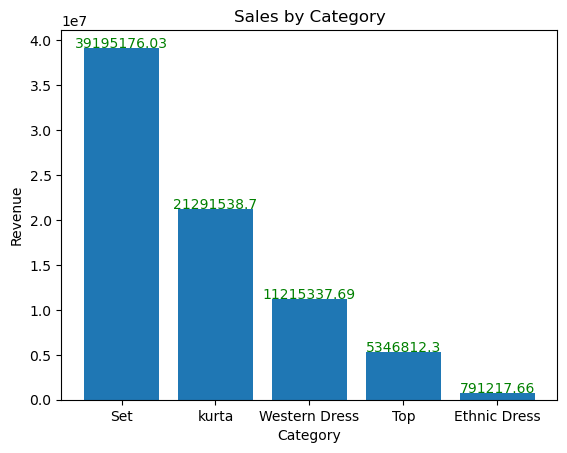

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Category_revenue.csv")

plt.figure()
plt.bar(df['Category'], df['Revenue'])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

for i, v in enumerate(df['Revenue']):
    plt.text(i, v, str(round(v,2)), ha='center', color="Green")

plt.savefig("images/category_sales.png", dpi=300, bbox_inches='tight')
plt.show()

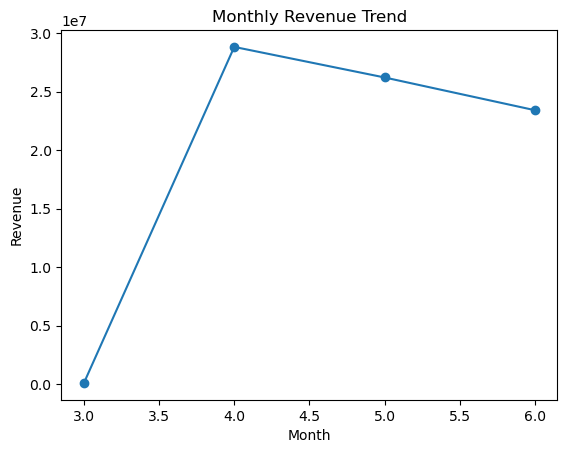

In [76]:
df = pd.read_csv("Monthly_trend.csv")

plt.figure()
plt.plot(df['Months'], df['Revenue'], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig("images/monthly_trend.png", dpi=300, bbox_inches='tight')
plt.show()

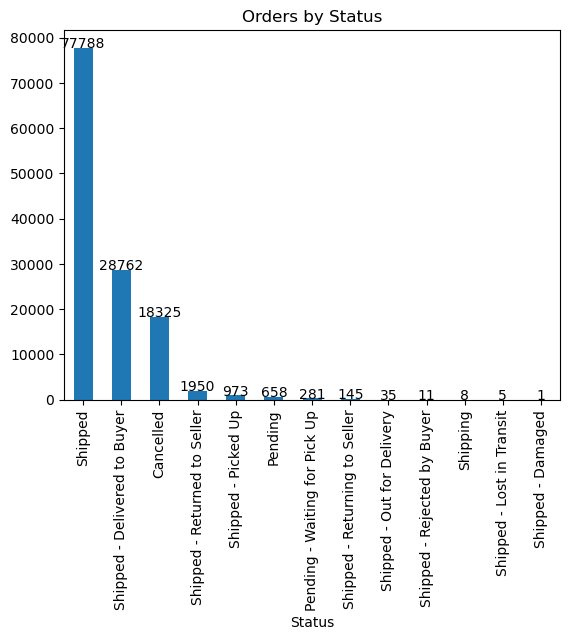

In [77]:
df = pd.read_csv("cleaned_amazon_sales.csv")

status_counts = df['Status'].value_counts()

plt.figure()
status_counts.plot(kind='bar')
plt.title("Orders by Status")

for i, v in enumerate(status_counts):
    plt.text(i, v, str(v), ha='center')

plt.savefig("images/order_status.png", dpi=300, bbox_inches='tight')
plt.show()

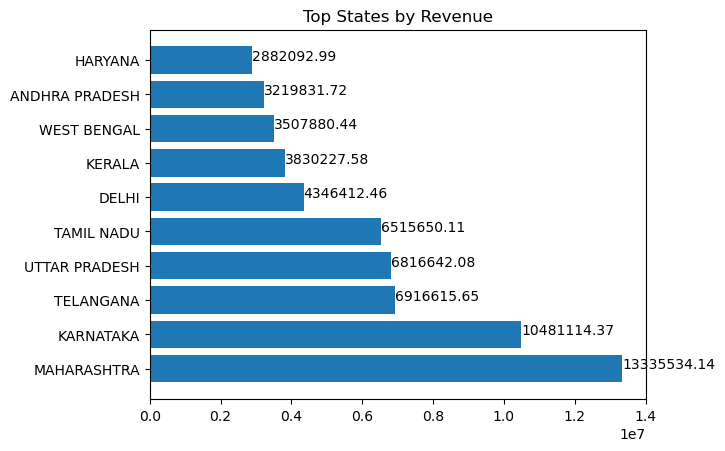

In [78]:
df = pd.read_csv("State_revenue.csv")

df = df.sort_values(by='Revenue', ascending=False).head(10)

plt.figure()
plt.barh(df['ship-state'], df['Revenue'])
plt.title("Top States by Revenue")

for i, v in enumerate(df['Revenue']):
    plt.text(v, i, str(round(v,2)))

plt.savefig("images/top_states.png", dpi=300, bbox_inches='tight')
plt.show()

In [86]:
df = pd.read_sql(query, conn)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

C:\Users\INNO\AppData\Local\Temp\ipykernel_11908\968032073.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [87]:
# Date features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day_name'] = df['Date'].dt.day_name()

# Revenue bucket
df['order_value_type'] = df['Amount'].apply(lambda x:
    'Low' if x < 500 else 'Medium' if x <= 2000 else 'High')

# Delivery flag
df['is_delivered'] = df['Status'].apply(lambda x: 1 if 'Delivered' in str(x) else 0)

# Cancel flag
df['is_cancelled'] = df['Status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

df.head()

,order_id,Date,Status,Fulfilment,Sales_channel,ship_service_level,Style,SKU,Category,Size,...,B2B,fulfilled-by,Unnamed: 22,order_date,year,month,day_name,order_value_type,is_delivered,is_cancelled
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,FALSE,Easy Ship,,2022-04-30,2022,4,Saturday,Medium,0,1
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,FALSE,Easy Ship,,2022-04-30,2022,4,Saturday,Low,1,0
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,TRUE,,,2022-04-30,2022,4,Saturday,Low,0,0
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,FALSE,Easy Ship,,2022-04-30,2022,4,Saturday,Medium,0,1
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,FALSE,,,2022-04-30,2022,4,Saturday,Medium,0,0


In [96]:
cols_to_drop = [
    'ASIN',
    'promotion-ids',
    'ship-postal-code',
    'currency'
]
df.drop(columns= (cols_to_drop), inplace=True)
df.isnull().sum()

order_id              0
Date                  0
Status                0
Fulfilment            0
Sales_channel         0
ship_service_level    0
Style                 0
Category              0
Size                  0
Courier_status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
ship-country          0
B2B                   0
fulfilled-by          0
order_date            0
year                  0
month                 0
day_name              0
order_value_type      0
is_delivered          0
is_cancelled          0
dtype: int64

In [98]:
df.columns = df.columns.str.strip().str.lower().str.replace('-', '_')

In [99]:
df.isnull().sum()

order_id              0
date                  0
status                0
fulfilment            0
sales_channel         0
ship_service_level    0
style                 0
category              0
size                  0
courier_status        0
qty                   0
amount                0
ship_city             0
ship_state            0
ship_country          0
b2b                   0
fulfilled_by          0
order_date            0
year                  0
month                 0
day_name              0
order_value_type      0
is_delivered          0
is_cancelled          0
dtype: int64

In [100]:
df.to_csv("final_amazon_sales.csv", index=False)

In [102]:
df.groupby('month')['amount'].sum().sort_values(ascending=False)

month
4    28831249.32
5    26219850.75
6    23421223.38
3      101683.85
Name: amount, dtype: float64

In [103]:
df.groupby('order_value_type')['amount'].sum().sort_values(ascending=False)

order_value_type
Medium    61654428.47
Low       16782656.20
High        136922.63
Name: amount, dtype: float64

In [104]:
df.groupby('status').size()

status
Cancelled                        18325
Pending                            658
Pending - Waiting for Pick Up      281
Shipped                          77788
Shipped - Damaged                    1
Shipped - Delivered to Buyer     28762
Shipped - Lost in Transit            5
Shipped - Out for Delivery          35
Shipped - Picked Up                973
Shipped - Rejected by Buyer         11
Shipped - Returned to Seller      1950
Shipped - Returning to Seller      145
Shipping                             8
dtype: int64

In [105]:
df.groupby('ship_state')['amount'].sum().sort_values(ascending=False).head(10)

ship_state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: amount, dtype: float64

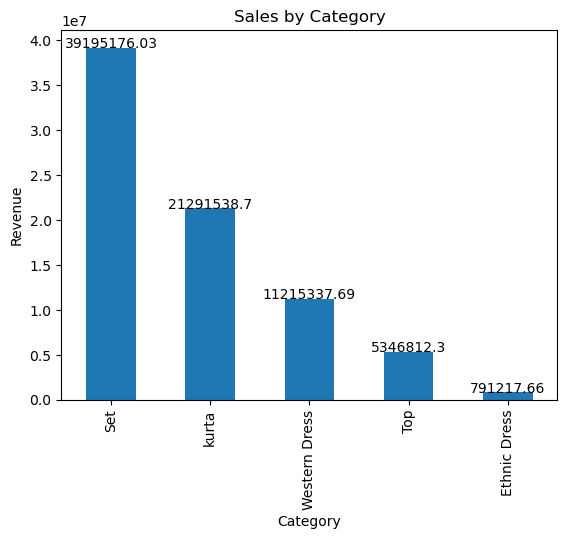

In [109]:
cat_sales = df.groupby('category')['amount'].sum().sort_values(ascending=False).head(5)

plt.figure()
cat_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

for i, v in enumerate(cat_sales):
    plt.text(i, v, str(round(v,2)), ha='center')

plt.savefig("images/sales_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

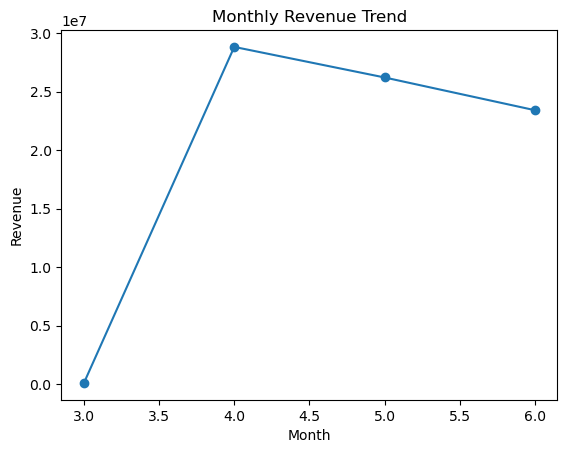

In [111]:
monthly_sales = df.groupby('month')['amount'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")


plt.savefig("images/monthly_trend.png", dpi=300, bbox_inches='tight')
plt.show()

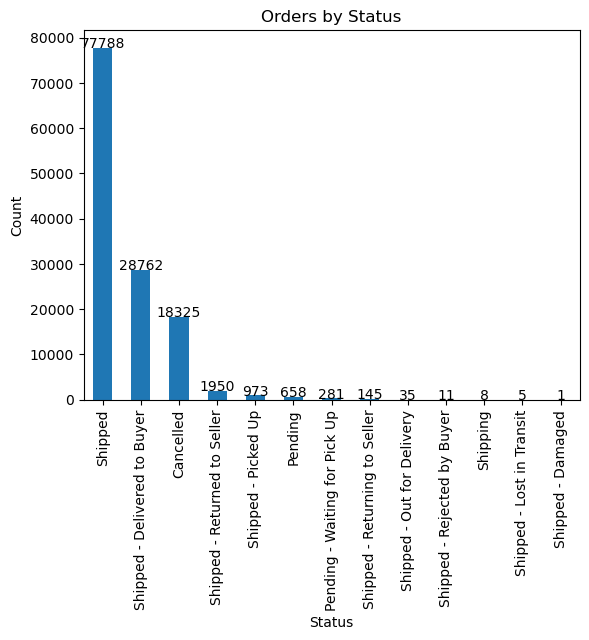

In [113]:
status_counts = df['status'].value_counts()

plt.figure()
status_counts.plot(kind='bar')

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Count")

for i, v in enumerate(status_counts):
    plt.text(i, v, str(v), ha='center')

plt.savefig("images/orders_by_status.png", dpi=300, bbox_inches='tight')
plt.show()

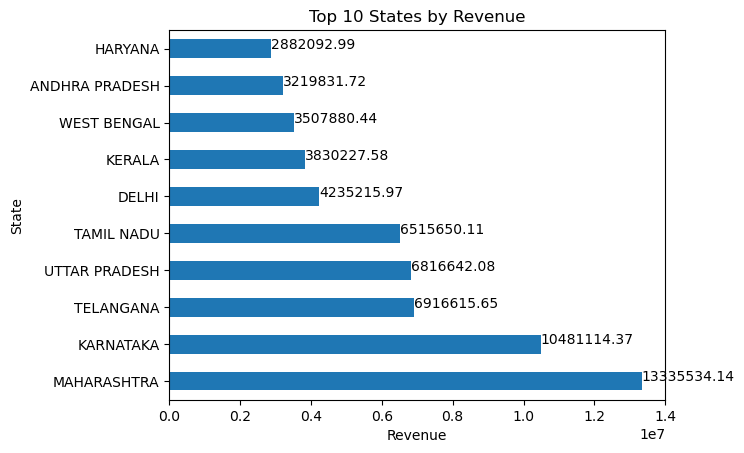

In [116]:
top_states = df.groupby('ship_state')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_states.plot(kind='barh')

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

for i, v in enumerate(top_states):
    plt.text(v, i, str(round(v,2)))

plt.savefig("images/top_states.png", dpi=300, bbox_inches='tight')
plt.show()

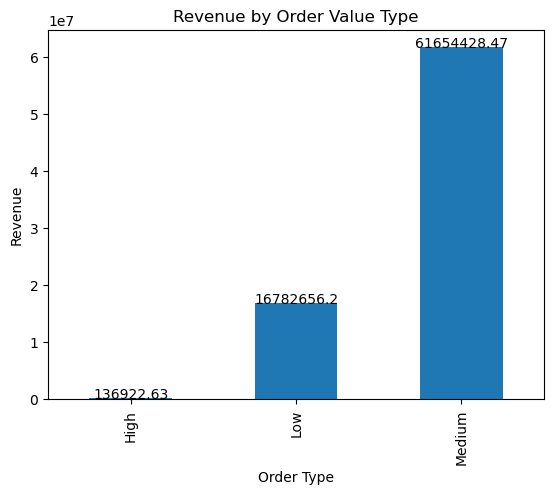

In [117]:
order_type = df.groupby('order_value_type')['amount'].sum()

plt.figure()
order_type.plot(kind='bar')

plt.title("Revenue by Order Value Type")
plt.xlabel("Order Type")
plt.ylabel("Revenue")

for i, v in enumerate(order_type):
    plt.text(i, v, str(round(v,2)), ha='center')

plt.savefig("images/order_value_type.png", dpi=300, bbox_inches='tight')
plt.show()

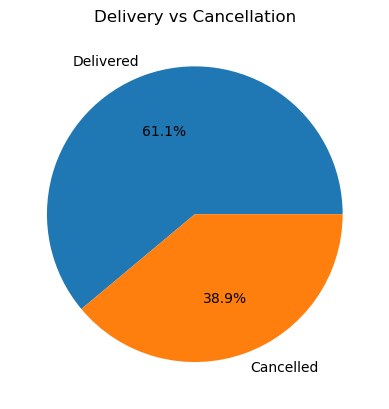

In [121]:
delivery = df[['is_delivered', 'is_cancelled']].sum()

plt.figure()
plt.pie(delivery, labels=['Delivered', 'Cancelled'], autopct='%1.1f%%')

plt.title("Delivery vs Cancellation")

plt.savefig("images/delivery_vs_cancel.png", dpi=300, bbox_inches='tight')
plt.show()